# Online Retail Customer Segmentation: Part 1 - Expanded EDA
This notebook provides a deep visual dive into the raw dataset. We focus on:
1. Identifying Data Gaps (Null Values).
2. Understanding Transactional Volume (Cancellations vs. Sales).
3. Analyzing Price and Quantity distributions using simple histograms and bar plots.

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to path
sys.path.append('../')
from src.utils import save_plot

# Style settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline

## 1. Missing Value Analysis
Before cleaning, let's visualize exactly where our data is missing. 
This justifies why we drop certain records for customer-level segmentation.

C:\Users\Aynorix\AppData\Local\Temp\ipykernel_19588\1401491382.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=null_percent.index, y=null_percent.values, palette='Reds_r')


Plot saved: ..\plots\eda\missing_values_bar.png


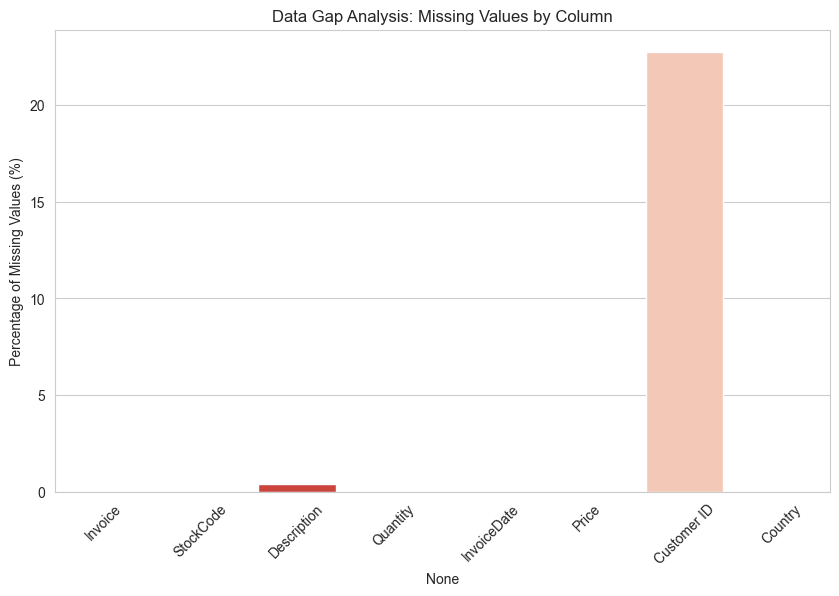

In [2]:
raw_path = os.path.join('..', 'data', 'raw', 'online_retail_II.csv')
df_raw = pd.read_csv(raw_path)

# Calculate nulls
null_counts = df_raw.isnull().sum()
null_percent = (null_counts / len(df_raw)) * 100

# Plotting Missing Values
plt.figure(figsize=(10, 6))
sns.barplot(x=null_percent.index, y=null_percent.values, palette='Reds_r')
plt.xticks(rotation=45)
plt.ylabel('Percentage of Missing Values (%)')
plt.title('Data Gap Analysis: Missing Values by Column')

save_plot('missing_values_bar.png', folder='eda')
plt.show()

## 2. Cancellations vs. Successful Transactions
In this dataset, invoices starting with 'C' are cancellations. 
Let's see the ratio of returned items to sold items.

C:\Users\Aynorix\AppData\Local\Temp\ipykernel_19588\2131372277.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x='Status', palette=['#2ecc71', '#e74c3c'])


Plot saved: ..\plots\eda\transaction_status_counts.png


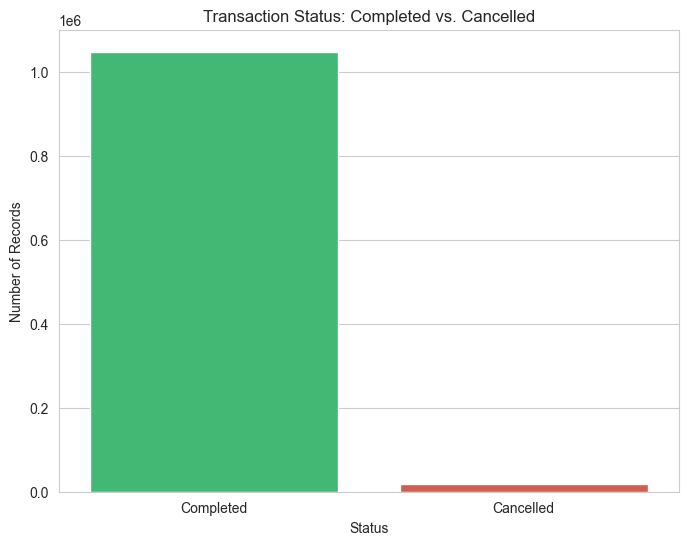

In [3]:
# Create a temporary column for status
df_raw['Status'] = df_raw['Invoice'].apply(lambda x: 'Cancelled' if str(x).startswith('C') else 'Completed')

plt.figure(figsize=(8, 6))
sns.countplot(data=df_raw, x='Status', palette=['#2ecc71', '#e74c3c'])
plt.title('Transaction Status: Completed vs. Cancelled')
plt.ylabel('Number of Records')

save_plot('transaction_status_counts.png', folder='eda')
plt.show()

## 3. Distribution of Unit Price (Histogram)
Understanding the price points. Most items in this retail store are low-cost.
*Note: We filter out extreme outliers (>50) just for the visualization to keep the chart readable.*

Plot saved: ..\plots\eda\unit_price_histogram.png


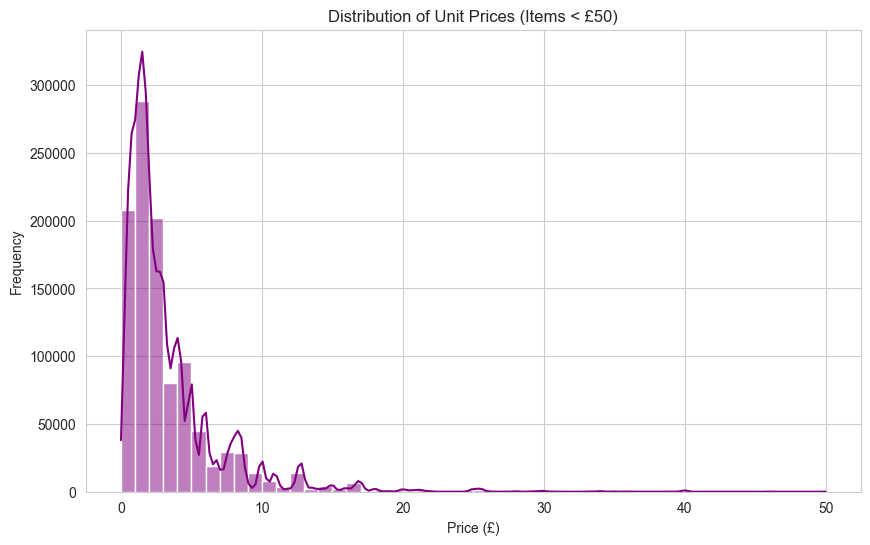

In [4]:
plt.figure(figsize=(10, 6))
# Filtering for visualization clarity (most items are < £20)
filtered_price = df_raw[(df_raw['Price'] > 0) & (df_raw['Price'] < 50)]

sns.histplot(filtered_price['Price'], bins=50, kde=True, color='purple')
plt.title('Distribution of Unit Prices (Items < £50)')
plt.xlabel('Price (£)')
plt.ylabel('Frequency')

save_plot('unit_price_histogram.png', folder='eda')
plt.show()

## 4. Top 10 Most Popular Products
What are people actually buying? This bar chart shows the most frequently appearing StockCodes.

C:\Users\Aynorix\AppData\Local\Temp\ipykernel_19588\3289724134.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='Blues_r')


Plot saved: ..\plots\eda\top_products_bar.png


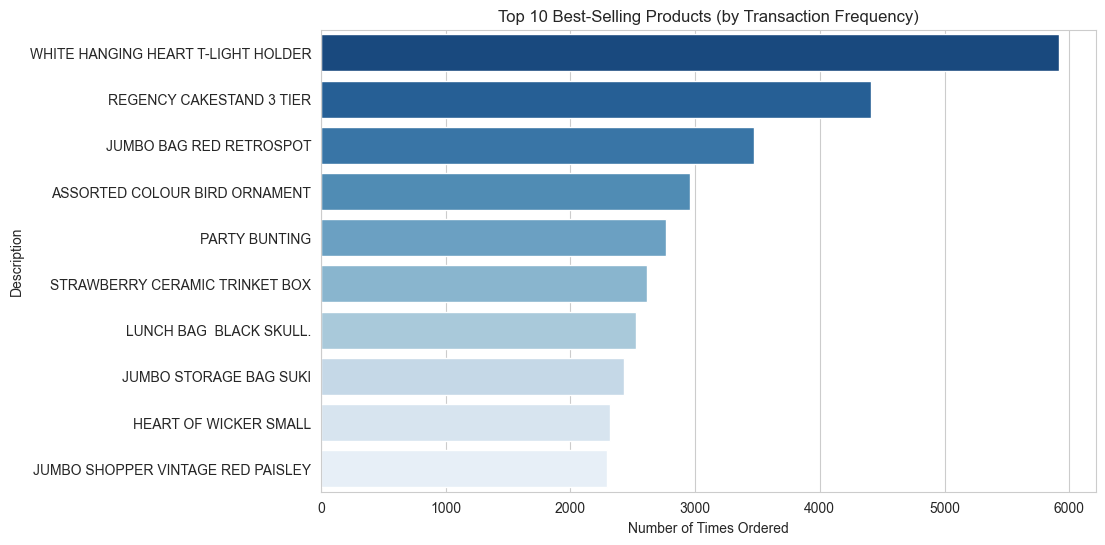

In [5]:
plt.figure(figsize=(10, 6))
top_products = df_raw['Description'].value_counts().head(10)

sns.barplot(x=top_products.values, y=top_products.index, palette='Blues_r')
plt.title('Top 10 Best-Selling Products (by Transaction Frequency)')
plt.xlabel('Number of Times Ordered')

save_plot('top_products_bar.png', folder='eda')
plt.show()

## 5. Daily Transaction Volume
Let's look at the "pulse" of the business. Are there specific days of the week 
that are busier?

C:\Users\Aynorix\AppData\Local\Temp\ipykernel_19588\2600985653.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x='DayOfWeek', order=days, palette='viridis')


Plot saved: ..\plots\eda\transactions_by_day.png


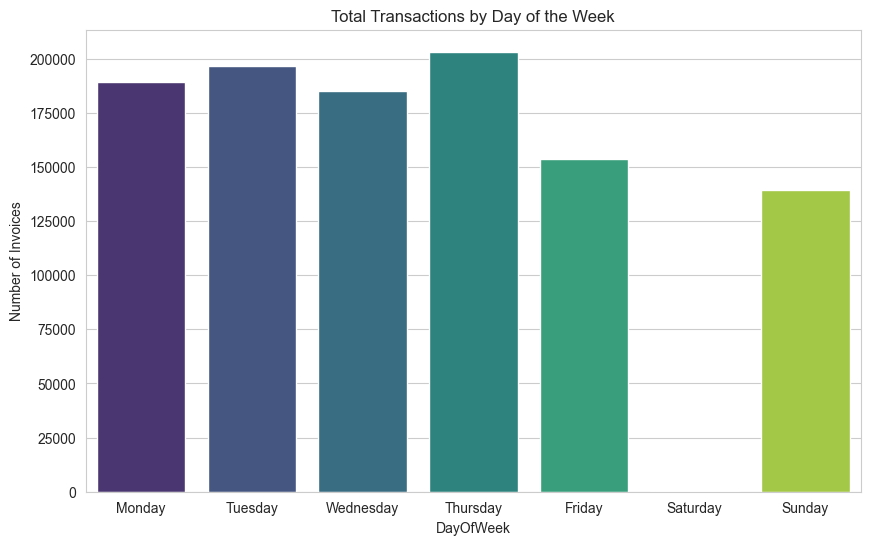

In [6]:
# Convert to datetime and extract Day of Week
df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'])
df_raw['DayOfWeek'] = df_raw['InvoiceDate'].dt.day_name()

# Sort order
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 6))
sns.countplot(data=df_raw, x='DayOfWeek', order=days, palette='viridis')
plt.title('Total Transactions by Day of the Week')
plt.ylabel('Number of Invoices')

save_plot('transactions_by_day.png', folder='eda')
plt.show()

## 6. Pre-Processing Summary
Now that we've seen the raw state, we run our engineering pipeline to prepare the 
RFM table for the next stage (Dimensionality Reduction).

Cleaned RFM DataFrame Sample:
             Recency  Frequency  Monetary  Diversity  C_Belgium  C_France  \
Customer ID                                                                 
12346.0          326         12  77556.46         26      False     False   
12347.0            2          8   5633.32        126      False     False   
12348.0           75          5   2019.40         28      False     False   
12349.0           19          4   4428.69        145      False     False   
12350.0          310          1    334.40         17      False     False   

             C_Germany  C_Other  C_Spain  C_United Kingdom  
Customer ID                                                 
12346.0          False    False    False              True  
12347.0          False     True    False             False  
12348.0          False     True    False             False  
12349.0          False     True    False             False  
12350.0          False     True    False             False  
Plo

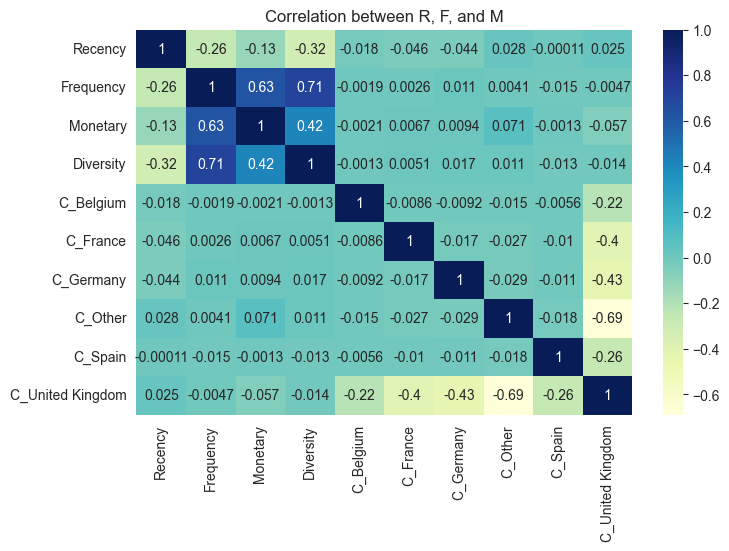

In [7]:
from src.preprocessing import run_preprocessing_pipeline

# Run the engineering script
rfm_df = run_preprocessing_pipeline(raw_path)

# Quick check on the result
print("Cleaned RFM DataFrame Sample:")
print(rfm_df.head())

# Final correlation check - Simple heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(rfm_df.corr(), annot=True, cmap='YlGnBu')
plt.title('Correlation between R, F, and M')

save_plot('rfm_heatmap.png', folder='eda')
plt.show()